# Plot simulation results

In [1]:
from config import *
import joblib
import pyvista as pv
import seaborn as sns

In [272]:
import matplotlib.pyplot as plt

datasource='grf'
strategy='fibonacci'
geometry='sphere'


data = pd.DataFrame([None])
for maptag in test_ranges:    

    for percentage in test_percentages:

        res = joblib.load(outdir + f'/{datasource}/{strategy}/{template}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')

        scores = res['performance'][1]
        pearson = res['performance'][0].iloc[0]
        spearman = res['performance'][0].iloc[1]
        ssim = res['performance'][0].iloc[2]
        r2 = res['performance'][0].iloc[3]
        rmse = res['performance'][0].iloc[4]
        ks = res['performance'][0].iloc[5]
        js = res['performance'][0].iloc[6]
        run_time = res['performance'][0].iloc[7]

        percentage_col = pd.DataFrame( [percentage] * len(scores), index=scores.index)
        maptag_col = pd.DataFrame( [maptag] * len(scores), index=scores.index)

        tmp_data = pd.concat( [ scores, pearson, spearman, ssim, r2, rmse, ks, js, run_time, percentage_col, maptag_col ], axis = 1)
        tmp_data.columns = ['score'] + metrics_to_consider + ['percentage', 'maptag']

        if data.empty: data = tmp_data
        else: data = pd.concat( [data, tmp_data] )


data = data.drop(0, axis = 0)
data = data.drop(0, axis = 1)

data['approach'] = data.index
data.index = range(len(data))


In [279]:
data

,score,pearson,spearman,ssim,r2,rmse,kolmogorov_smirnov,jensen_shannon,run_time,percentage,maptag,approach
0,0.678571,0.709273,0.758953,0.989799,0.030031,0.931594,0.483172,1.456110e-01,181.982903,2.0,25.0,swr
1,0.750000,0.449607,0.417173,0.991766,0.190752,0.850920,0.245028,1.870114e-01,0.002361,2.0,25.0,idw
2,0.678571,0.409486,0.396952,0.990024,0.090663,0.902008,0.131056,1.746333e-01,0.112176,2.0,25.0,rbf
3,0.392857,0.396186,0.394860,0.989393,0.020494,0.936163,0.118817,1.826577e-01,0.002195,2.0,25.0,knn
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,krige
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.833333,1.000000,1.000000,1.000000,1.000000,0.000541,0.001499,2.202460e-07,0.681286,50.0,100.0,rbf
116,0.666667,0.999550,0.999526,0.999987,0.998973,0.041841,0.007996,7.093773e-04,0.113899,50.0,100.0,idw
117,0.476190,0.999480,0.999487,0.999973,0.998632,0.048302,0.011994,8.113058e-04,0.004216,50.0,100.0,knn
118,0.357143,0.996244,0.997606,0.999921,0.992437,0.113559,0.009995,2.286794e-03,221.287510,50.0,100.0,regkrige


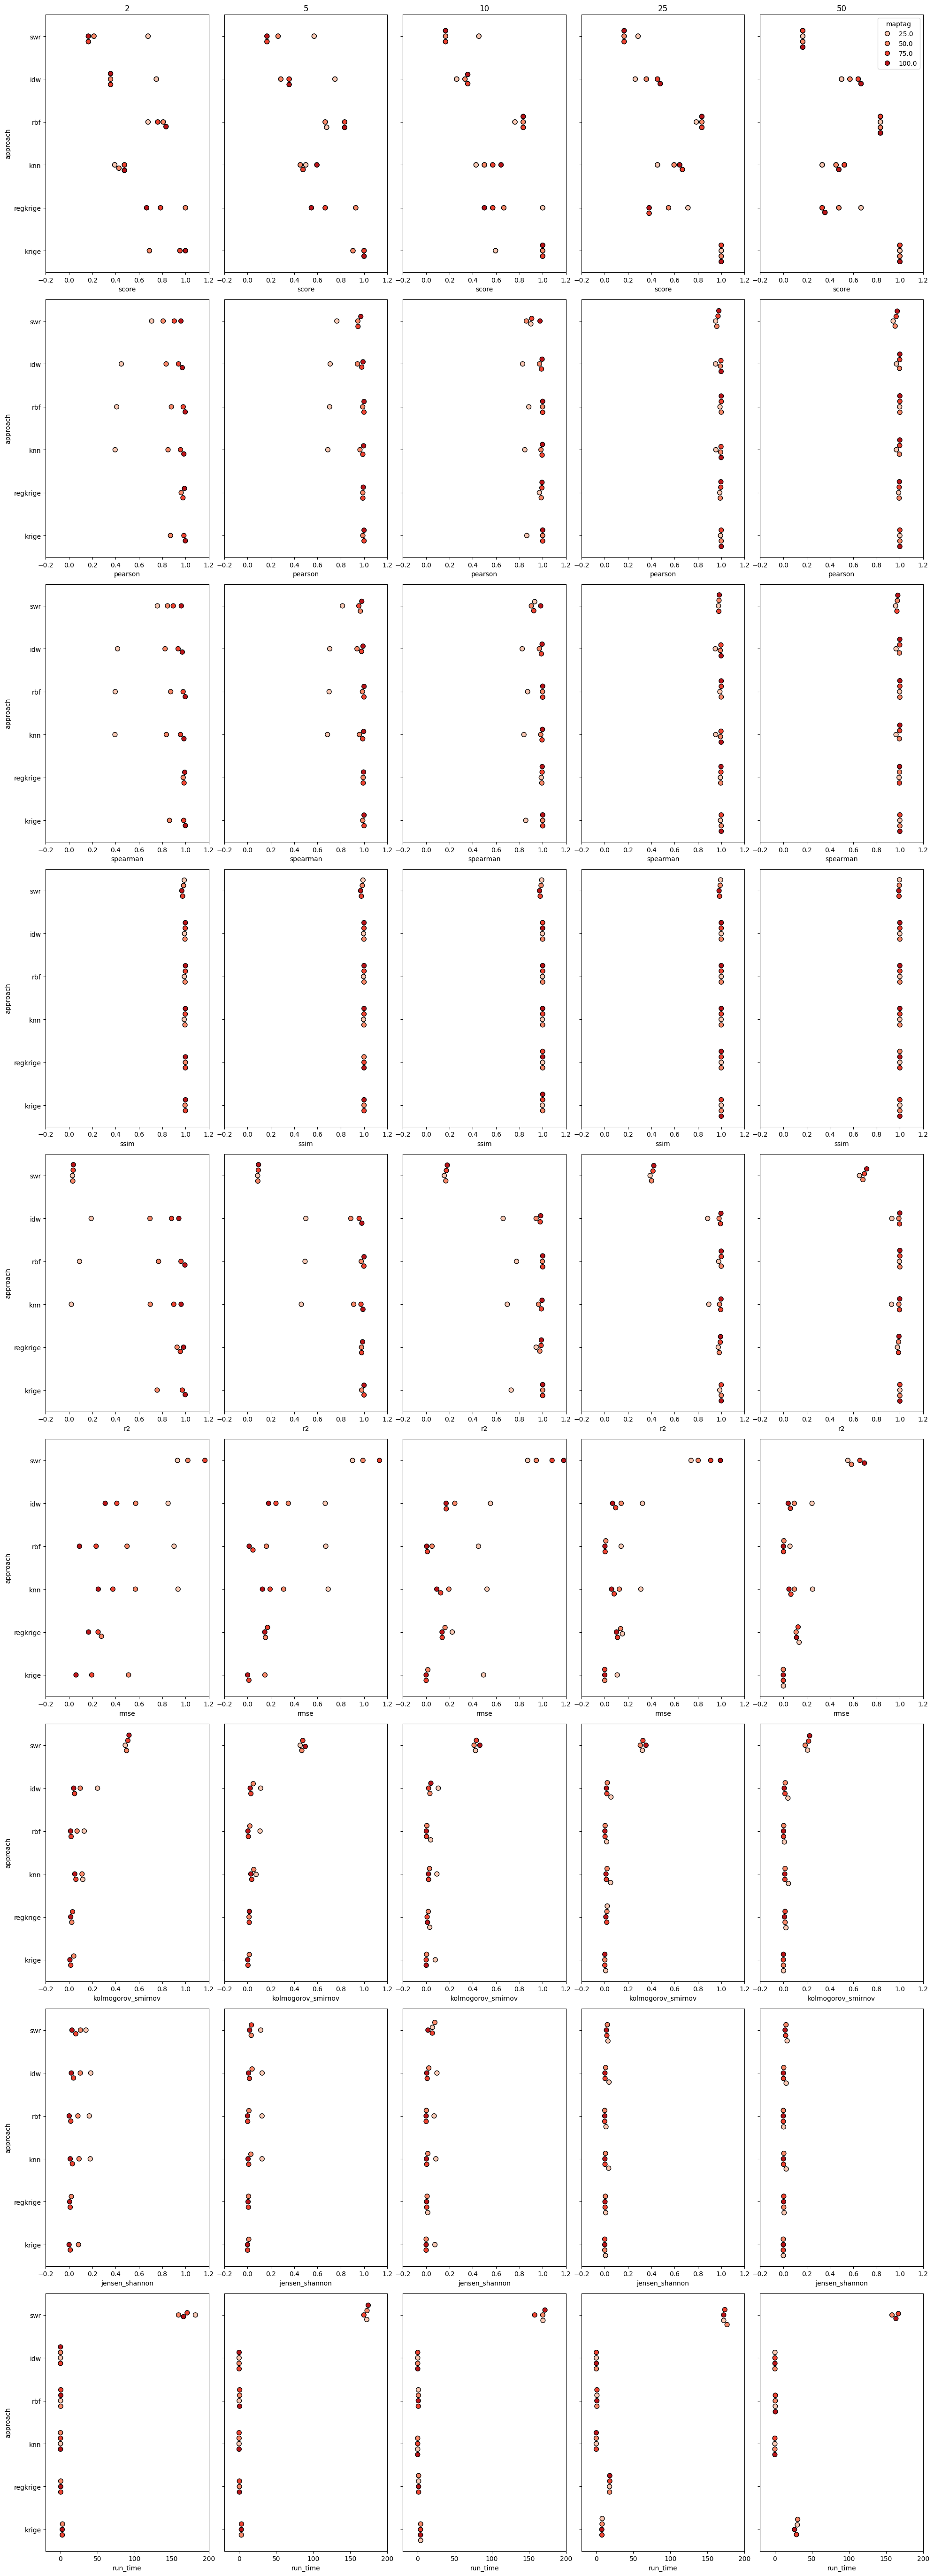

In [345]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(len(metrics_to_consider)+1, len(test_percentages), figsize = (20, 55), sharey = True)

grf_pal = sns.color_palette('Reds', n_colors = len(test_ranges))

for mi, metric in enumerate(['score'] + metrics_to_consider):
    for pi,percentage in enumerate(test_percentages):
        plotdt = data[data['percentage'] == percentage]
        if mi==0: 
            p = sns.swarmplot(plotdt, x = metric, y = 'approach', hue = 'maptag', \
                    edgecolor = 'k', linewidth =1, \
                    palette = grf_pal, size = 7, legend=False, ax=axs[mi,pi])
            p.set_xlim(-.2,1.2)
            p.set_title(percentage)
        if mi==0 and pi==len(test_percentages)-1: 
            p= sns.swarmplot(plotdt, x = metric, y = 'approach', hue = 'maptag', \
                    edgecolor = 'k', linewidth =1, \
                    palette = grf_pal, size = 7, legend=True, ax=axs[mi,pi])
            p.set_xlim(-.2,1.2)
        if mi==len(metrics_to_consider):
            p=sns.swarmplot(plotdt, x = metric, y = 'approach', hue = 'maptag', \
                    edgecolor = 'k', linewidth =1, \
                    palette = grf_pal, size = 7, legend=False, ax=axs[mi,pi])
            p.set_xlim(-20,200)
        else:
            p = sns.swarmplot(plotdt, x = metric, y = 'approach', hue = 'maptag', \
                        edgecolor = 'k', linewidth =1, \
                        palette = grf_pal, size = 7, legend=False, ax=axs[mi,pi])
            p.set_xlim(-.2,1.2)
plt.tight_layout()
plt.savefig(projdir + f'/figs/{template}_{geometry}_{datasource}_samp-{strategy}_performance_moreinfo_v2.svg')

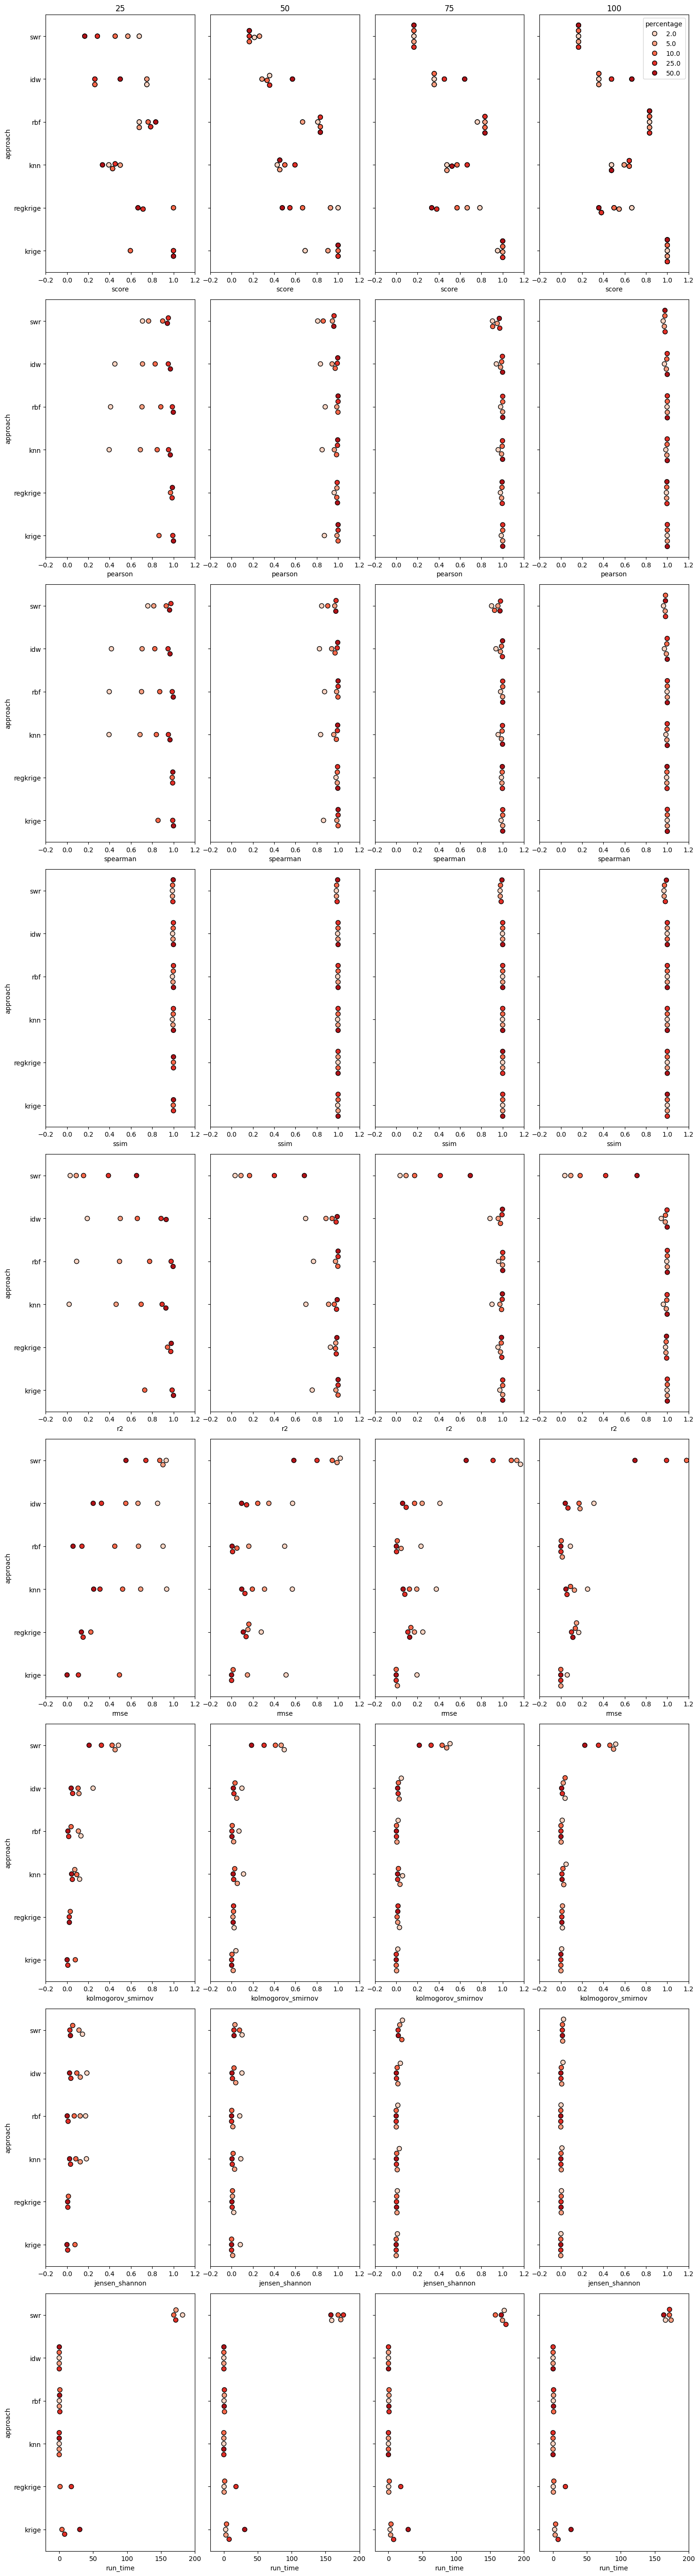

In [336]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(len(metrics_to_consider)+1, len(test_ranges), figsize = (15, 55), sharey = True)

grf_pal = sns.color_palette('Reds', n_colors = len(test_percentages))

for mi, metric in enumerate(['score'] + metrics_to_consider):
    for mj, maptag in enumerate(test_ranges):
        plotdt = data[data['maptag'] == maptag]
        if mi==0: 
            p = sns.swarmplot(plotdt, x = metric, y = 'approach', hue = 'percentage', \
                    edgecolor = 'k', linewidth =1, \
                    palette = grf_pal, size = 7, legend=False, ax=axs[mi,mj])
            p.set_xlim(-.2,1.2)
            p.set_title(maptag)
        if mi==0 and mj==len(test_ranges)-1: 
            p= sns.swarmplot(plotdt, x = metric, y = 'approach', hue = 'percentage', \
                    edgecolor = 'k', linewidth =1, \
                    palette = grf_pal, size = 7, legend=True, ax=axs[mi,mj])
            p.set_xlim(-.2,1.2)
        if mi==len(metrics_to_consider):
            p=sns.swarmplot(plotdt, x = metric, y = 'approach', hue = 'percentage', \
                    edgecolor = 'k', linewidth =1, \
                    palette = grf_pal, size = 7, legend=False, ax=axs[mi,mj])
            p.set_xlim(-20,200)
        else:
            p = sns.swarmplot(plotdt, x = metric, y = 'approach', hue = 'percentage', \
                        edgecolor = 'k', linewidth =1, \
                        palette = grf_pal, size = 7, legend=False, ax=axs[mi,mj])
            p.set_xlim(-.2,1.2)
plt.tight_layout()
plt.savefig(projdir + f'/figs/{template}_{geometry}_{datasource}_samp-{strategy}_performance_moreinfo.svg')

In [329]:
import numpy as np
data['category'] = np.empty(len(data))
for rowid in range(len(data)):
    if data.at[rowid, 'approach'] in ['krige', 'regkrige', 'swr']: data.at[rowid, 'category'] = 'spatial'
    if data.at[rowid, 'approach'] in ['idw', 'knn', 'rbf']: data.at[rowid, 'category'] = 'deterministic'
        

In [330]:
data.groupby('approach')['score'].mean().sort_values().index

Index(['swr', 'idw', 'knn', 'regkrige', 'rbf', 'krige'], dtype='object', name='approach')

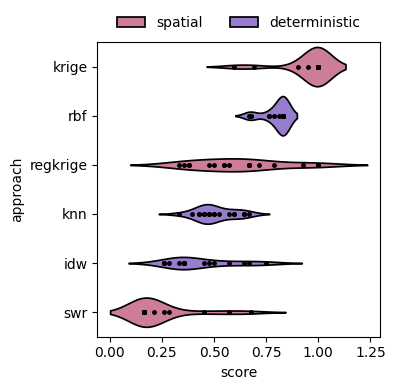

In [340]:
colors = ["palevioletred", "mediumpurple"]
fig, ax = plt.subplots(1,1,figsize = (4,4))
sns.violinplot(data, x='score', y ='approach', hue = 'category', order=data.groupby('approach')['score'].mean().sort_values(ascending=False).index, inner = 'point', palette = sns.color_palette(colors), linecolor = 'k', ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
#plt.show()
fig.tight_layout()
#plt.show()
plt.savefig(projdir + f'/figs/{template}_{geometry}_{datasource}_samp-{strategy}_summary.svg')

In [343]:
data.to_csv(projdir + f'/results/{template}_{geometry}_{datasource}_samp-{strategy}_performance.csv')